# Dense And Sparse Correspondence
In this tutorial we show how DINOv3 features can be used to establish correspondences between two objects.

### Setup

Let's start by loading some pre-requisites and checking the DINOv3 repository location:
- `local` if `DINOV3_LOCATION` environment variable was set to work with a local version of DINOv3 repository;
- `github` if the code should be loaded via torch hub.

In [1]:
import pickle
import os
import urllib

import numpy as np
from matplotlib.patches import ConnectionPatch
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA

import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from tqdm import tqdm

DINOV3_GITHUB_LOCATION = "facebookresearch/dinov3"

if os.getenv("DINOV3_LOCATION") is not None:
    DINOV3_LOCATION = os.getenv("DINOV3_LOCATION")
else:
    DINOV3_LOCATION = DINOV3_GITHUB_LOCATION

print(f"DINOv3 location set to {DINOV3_LOCATION}")

DINOv3 location set to facebookresearch/dinov3


### Model Loading
We load the DINOv3 ViT-L model. Feel free to try other DINOv3 models as well!

In [2]:
# examples of available DINOv3 models:
MODEL_DINOV3_VITS = "dinov3_vits16"
MODEL_DINOV3_VITSP = "dinov3_vits16plus"
MODEL_DINOV3_VITB = "dinov3_vitb16"
MODEL_DINOV3_VITL = "dinov3_vitl16"
MODEL_DINOV3_VITHP = "dinov3_vith16plus"
MODEL_DINOV3_VIT7B = "dinov3_vit7b16"

# we take DINOv3 ViT-B (our CAM model is base)
MODEL_NAME = MODEL_DINOV3_VITB

import sys
sys.path.append("/Users/thallessilva/workspace/CAM_dinov3")
from cam.models.vision_transformer import vit_base
import torch

model = vit_base(patch_size=16, num_register_tokens=0)
ckpt_path = '/Users/thallessilva/workspace/CAM_dinov3/experiments/vitb_refinement_g=0.15_l=0.15/eval/training_62499/teacher_checkpoint.pth'
ckpt = torch.load(ckpt_path, map_location='cpu')

state_dict = {k.replace('backbone.', ''): v for k, v in ckpt['teacher'].items() if k.startswith('backbone.')}
msg = model.load_state_dict(state_dict, strict=False)
print("Model loaded with msg:", msg)

model.eval()
if torch.cuda.is_available():
    model.cuda()



Ignored kwargs: {'num_register_tokens': 0}


Model loaded with msg: _IncompatibleKeys(missing_keys=[], unexpected_keys=['blocks.0.ls1.gamma', 'blocks.0.ls2.gamma', 'blocks.1.ls1.gamma', 'blocks.1.ls2.gamma', 'blocks.2.ls1.gamma', 'blocks.2.ls2.gamma', 'blocks.3.ls1.gamma', 'blocks.3.ls2.gamma', 'blocks.4.ls1.gamma', 'blocks.4.ls2.gamma', 'blocks.5.ls1.gamma', 'blocks.5.ls2.gamma', 'blocks.6.ls1.gamma', 'blocks.6.ls2.gamma', 'blocks.7.ls1.gamma', 'blocks.7.ls2.gamma', 'blocks.8.ls1.gamma', 'blocks.8.ls2.gamma', 'blocks.9.ls1.gamma', 'blocks.9.ls2.gamma', 'blocks.10.ls1.gamma', 'blocks.10.ls2.gamma', 'blocks.11.ls1.gamma', 'blocks.11.ls2.gamma'])


### Data Loading
Now that we have the model set up, let's load the data. It consists of two image / mask pairs:


In [3]:
image_left_uri = "https://dl.fbaipublicfiles.com/dinov3/notebooks/dense_sparse_matching/image_left.jpg"
mask_left_uri = "https://dl.fbaipublicfiles.com/dinov3/notebooks/dense_sparse_matching/image_left_fg.png"
image_right_uri = "https://dl.fbaipublicfiles.com/dinov3/notebooks/dense_sparse_matching/image_right.jpg"
mask_right_uri = "https://dl.fbaipublicfiles.com/dinov3/notebooks/dense_sparse_matching/image_right_fg.png"

def load_image_from_url(url: str) -> Image:
    with urllib.request.urlopen(url) as f:
        return Image.open(f)


image_left = load_image_from_url(image_left_uri)
mask_left = load_image_from_url(mask_left_uri)

image_right = load_image_from_url(image_right_uri)
mask_right = load_image_from_url(mask_right_uri)

Let's visualize the two images and the corresponding masks:

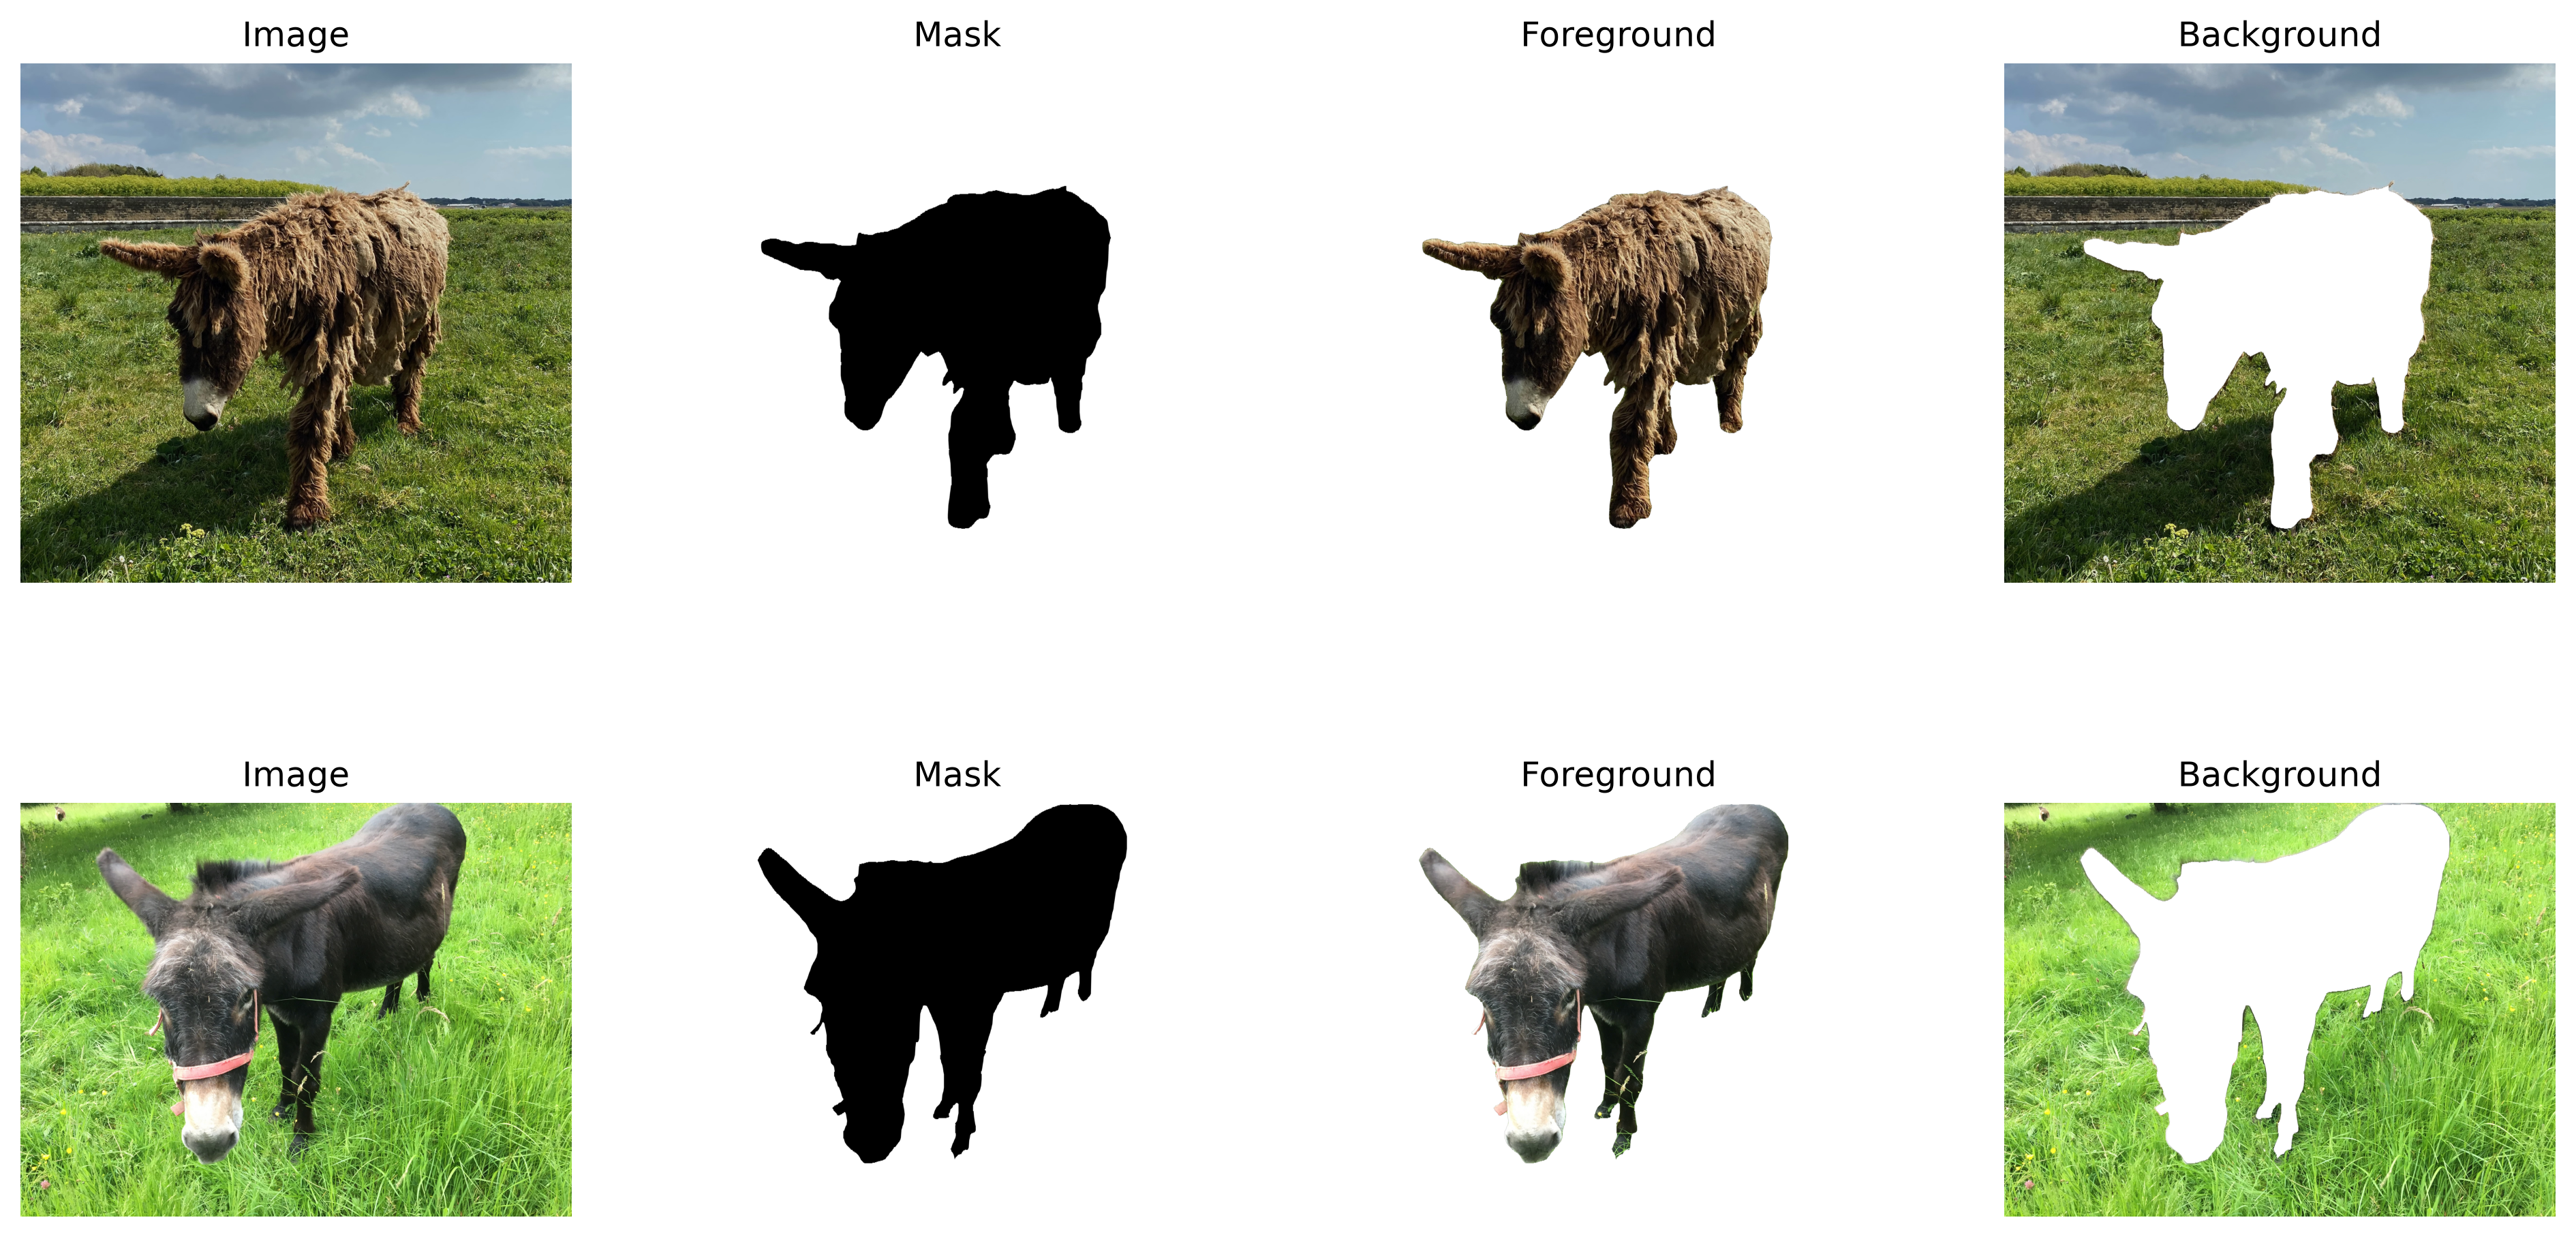

In [4]:
plt.figure(figsize=(16, 8), dpi=300)

for j, (image, mask) in enumerate([(image_left, mask_left), (image_right, mask_right)]):
    foreground = Image.composite(image, mask, mask)
    mask_bg_np = np.copy(np.array(mask))
    mask_bg_np[:, :, 3] = 255 - mask_bg_np[:, :, 3]
    mask_bg = Image.fromarray(mask_bg_np)
    background = Image.composite(image, mask_bg, mask_bg)

    data_to_show = [image, mask, foreground, background]
    data_labels = ["Image", "Mask", "Foreground", "Background"]


    for i in range(len(data_to_show)):
        plt.subplot(2, len(data_to_show), 4 * j + i + 1)
        plt.imshow(data_to_show[i])
        plt.axis('off')
        plt.title(data_labels[i], fontsize=12)
        
plt.show()

### Data Transforms

Since our models run with a patch size of 16, we have to quantize the masks to a 16x16 pixels grid. To achieve this, we define:
- the resize transform to resize an image such that it aligns well with the 16x16 grid;
- a uniform 16x16 conv layer as a [box blur filter](https://en.wikipedia.org/wiki/Box_blur) with stride equal to the patch size.

In [5]:
PATCH_SIZE = 16
IMAGE_SIZE = 768

# quantization filter for the given patch size
patch_quant_filter = torch.nn.Conv2d(1, 1, PATCH_SIZE, stride=PATCH_SIZE, bias=False)
patch_quant_filter.weight.data.fill_(1.0 / (PATCH_SIZE * PATCH_SIZE))

# image resize transform to dimensions divisible by patch size
def resize_transform(
    mask_image: Image,
    image_size: int = IMAGE_SIZE,
    patch_size: int = PATCH_SIZE,
) -> torch.Tensor:
    w, h = mask_image.size
    h_patches = int(image_size / patch_size)
    w_patches = int((w * image_size) / (h * patch_size))
    return TF.to_tensor(TF.resize(mask_image, (h_patches * patch_size, w_patches * patch_size)))

### Extracting Features
Now we will extract for each of the two images mask values, as well as the patch features. That involves running the dense feature extraction with our model using the following code snippet :

```
with torch.inference_mode():        
    feats = model.get_intermediate_layers(img, n=range(n_layers), reshape=True, norm=True)
    patch_features.append(feats[-1].squeeze().detach().cpu())
```
Each tensor of patch features thus has shape `[D, H, W]`, where `D` is feature dimensionality, and `H` and `W` are image dimensions in the number of patches.

In [6]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

MODEL_TO_NUM_LAYERS = {
    MODEL_DINOV3_VITS: 12,
    MODEL_DINOV3_VITSP: 12,
    MODEL_DINOV3_VITB: 12,
    MODEL_DINOV3_VITL: 24,
    MODEL_DINOV3_VITHP: 32,
    MODEL_DINOV3_VIT7B: 40,
}

n_layers = MODEL_TO_NUM_LAYERS[MODEL_NAME]

patch_mask_values = []
patch_features = []

with torch.inference_mode():
    with torch.autocast(device_type='cpu', dtype=torch.float32):
        for image, mask in tqdm([(image_left, mask_left), (image_right, mask_right)], desc="Processing images"):
            # processing mask
            mask = mask.split()[-1]
            mask_resized = resize_transform(mask)
            #mask_quantized = patch_quant_filter(mask_resized).squeeze().view(-1).detach().cpu()
            mask_quantized = patch_quant_filter(mask_resized).squeeze().detach().cpu()
            patch_mask_values.append(mask_quantized)
            # processing image
            image = image.convert('RGB')
            image_resized = resize_transform(image)
            image_resized = TF.normalize(image_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)
            image_resized = image_resized.unsqueeze(0).to('cpu')

            feats = model.get_intermediate_layers(image_resized, n=range(n_layers), reshape=True, norm=True)
            dim = feats[-1].shape[1]
            #patch_features.append(feats[-1].squeeze().view(dim, -1).permute(1,0).detach().cpu())
            patch_features.append(feats[-1].squeeze().detach().cpu())


/var/folders/l_/zpww6dgx2dv69kslh10rcg640000gn/T/ipykernel_93423/3372249611.py:19: UserWarning: In CPU autocast, but the target dtype is not supported. Disabling autocast.
CPU Autocast only supports dtypes of torch.bfloat16, torch.float16 currently.
  with torch.autocast(device_type='cpu', dtype=torch.float32):


Processing images:   0%|                                 | 0/2 [00:00<?, ?it/s]

Processing images:  50%|████████████▌            | 1/2 [00:00<00:00,  1.23it/s]

Processing images: 100%|█████████████████████████| 2/2 [00:01<00:00,  1.04it/s]

Processing images: 100%|█████████████████████████| 2/2 [00:01<00:00,  1.06it/s]

### Matching Patches

For each patch within the foreground object in the left image, we search for the closest patch in the right image using [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity) between patch features. We select correspondences only for foreground objects.

In [7]:
MASK_FG_THRESHOLD = 0.5

patch_features[0] = F.normalize(patch_features[0], p=2, dim=0)
patch_features[1] = F.normalize(patch_features[1], p=2, dim=0)

heatmaps = torch.einsum(
    "k f, f h w -> k h w",
    patch_features[0].view(dim, -1).permute(1, 0),
    patch_features[1],
)

# compute 2D patch locations in the left image
n_patches_left = patch_features[0].shape[1] * patch_features[0].shape[2]
patch_indices_left = torch.arange(n_patches_left)
locs_2d_left = (
    torch.stack(
        (
            patch_indices_left // patch_features[0].shape[2],  # row
            patch_indices_left % patch_features[0].shape[2]    # column
        ),
        dim=-1
    ) + 0.5
) * PATCH_SIZE

# compute the corresponding 2D patch locations in the right image
patch_indices_right = torch.flatten(heatmaps, start_dim=-2).argmax(dim=-1)
locs_2d_right = (
    torch.stack(
        (
            patch_indices_right // patch_features[1].shape[2],  # row
            patch_indices_right % patch_features[1].shape[2]    # column
        ),
        dim=-1
    ) + 0.5
) * PATCH_SIZE

# foreground patches mask in the left image
patches_left_fg_selection = (patch_mask_values[0].view(-1) > MASK_FG_THRESHOLD)
# left image patches mask for patches that map to a foreground patch in the right image
patches_right_fg_selection = (patch_mask_values[1].view(-1)[patch_indices_right] > MASK_FG_THRESHOLD)
# select foreground left image patches that map to foreground right image patches
patches_fg_selection = (patches_left_fg_selection * patches_right_fg_selection)

# select (row, col) coordinates for the matched patches
locs_2d_left_fg = locs_2d_left[patches_fg_selection, :]
locs_2d_right_fg = locs_2d_right[patches_fg_selection, :]

### Dense Correspondence
We now show dense correspondences between patches using the color space estimated through PCA over foreground patches in the left image. Closer colors correspond to more similar patches.

In [8]:
pca = PCA(n_components=3, whiten=True)
fg_patches_left = patch_features[0].view(dim, -1).permute(1, 0)[patches_fg_selection]
pca.fit(fg_patches_left)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",True
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD s

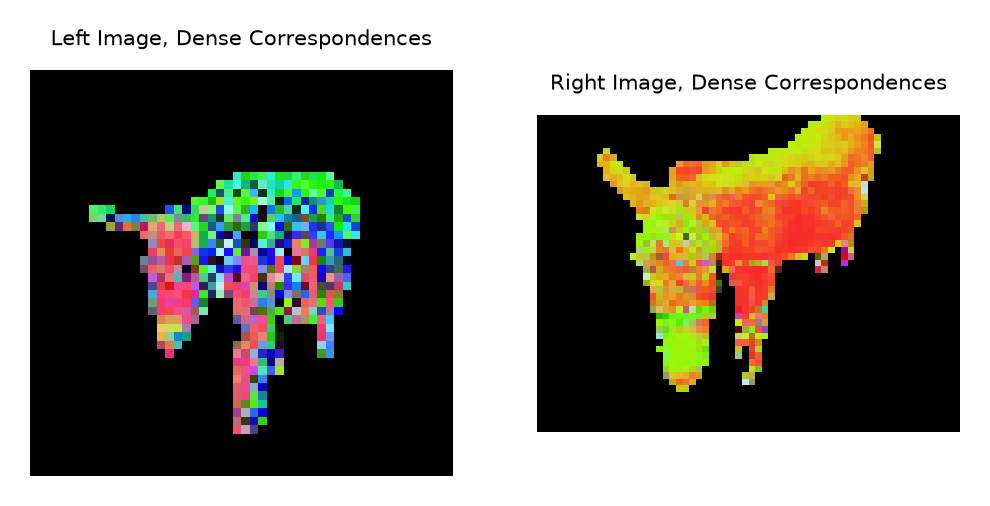

In [9]:
# get colors for the left image
h_patches_left = patch_features[0].shape[1]
w_patches_left = patch_features[0].shape[2]
x_left = patch_features[0].view(dim, -1).permute(1, 0)
projected_image_left = torch.from_numpy(
    pca.transform(x_left.numpy())
).view(h_patches_left, w_patches_left, 3)
# multiply by 2.0 and pass through a sigmoid to get vibrant colors 
projected_image_left = torch.nn.functional.sigmoid(projected_image_left.mul(2.0)).permute(2, 0, 1)

# get colors for the right image
h_patches_right = patch_features[1].shape[1]
w_patches_right = patch_features[1].shape[2]
x_right = patch_features[1].view(dim, -1).permute(1, 0)
projected_image_right = torch.from_numpy(
    pca.transform(x_right.numpy())
).view(h_patches_right, w_patches_right, 3)
projected_image_right = torch.nn.functional.sigmoid(projected_image_right.mul(2.0)).permute(2, 0, 1)

# apply foreground masks to both visualizations
projected_image_left *= (patch_mask_values[0] > MASK_FG_THRESHOLD)[None, :, :]
projected_image_right *= (patch_mask_values[1] > MASK_FG_THRESHOLD)[None, :, :]

plt.figure(figsize=(4, 2), dpi=300)
plt.subplot(1, 2, 1)
plt.imshow(projected_image_left.permute(1, 2, 0))
plt.title("Left Image, Dense Correspondences", fontsize=5)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(projected_image_right.permute(1, 2, 0))
plt.title("Right Image, Dense Correspondences", fontsize=5)
plt.axis('off')
plt.show()

### Sparse Correspondence

Finally, we show the established correspondences via the sparse set of matched points.

Non-stratified points: (399, 2)
Stratified points: (54, 2)


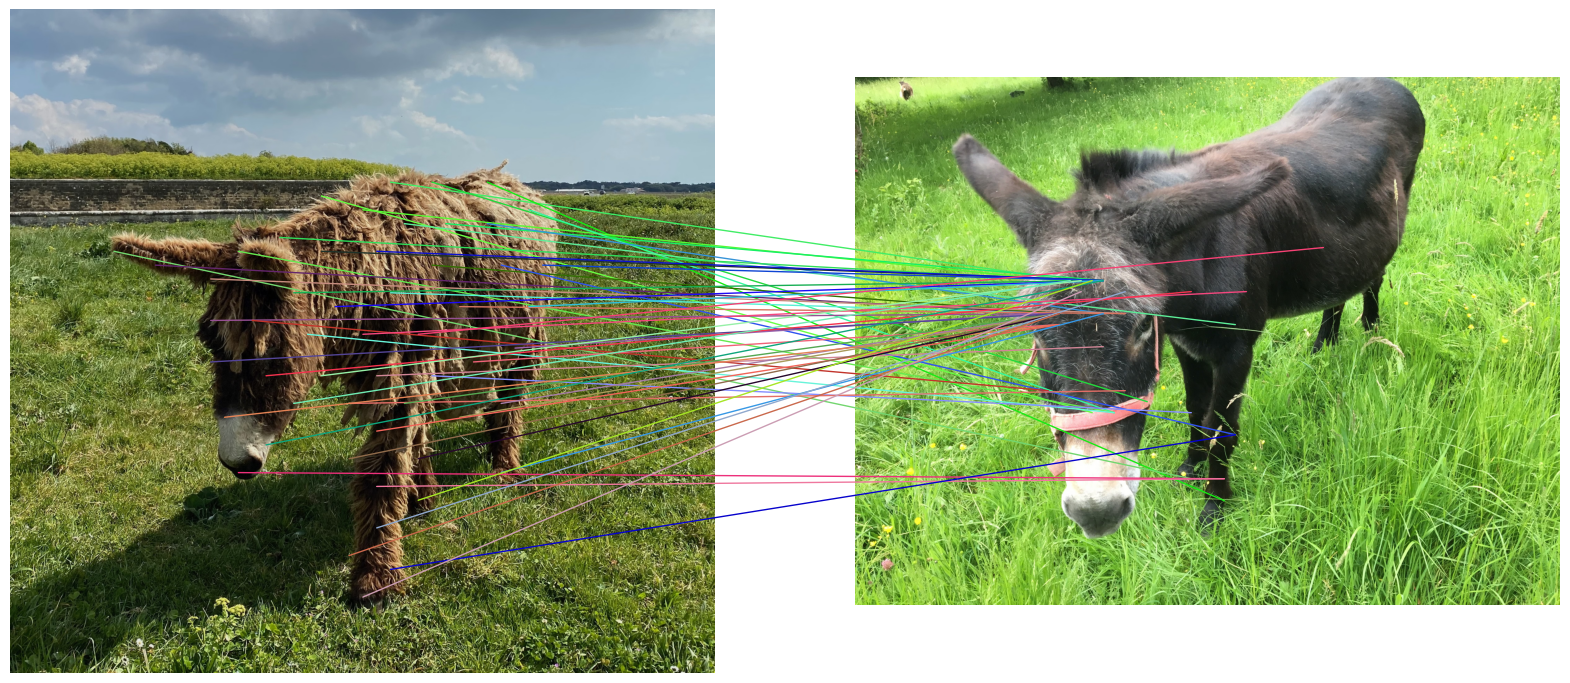

In [10]:
# image scale to go from patches to the original image coordinates
scale_left = image_left.height / IMAGE_SIZE
scale_right = image_right.height / IMAGE_SIZE


STRATIFY_DISTANCE_THRESHOLD = 100.0

def compute_distances_l2(X, Y, X_squared_norm, Y_squared_norm):
    distances = -2 * X @ Y.T
    distances.add_(X_squared_norm[:, None]).add_(Y_squared_norm[None, :])
    return distances


def stratify_points(pts_2d: torch.Tensor, threshold: float = 100.0) -> torch.Tensor:
    # pts_2d: [N, 2]
    n = len(pts_2d)
    max_value = threshold + 1
    pts_2d_sq_norms = torch.linalg.vector_norm(pts_2d, dim=1)
    pts_2d_sq_norms.square_()
    distances = compute_distances_l2(pts_2d, pts_2d, pts_2d_sq_norms, pts_2d_sq_norms)
    distances.fill_diagonal_(max_value)
    distances_mask = torch.empty((n, n), dtype=pts_2d.dtype, device=pts_2d.device)
    torch.le(distances, threshold, out=distances_mask)
    ones_vec = torch.ones(n, device=pts_2d.device, dtype=pts_2d.dtype)
    counts_vec = torch.mv(distances_mask, ones_vec)
    indices_mask = np.ones(n)
    while torch.any(counts_vec).item():
        index_max = torch.argmax(counts_vec).item()
        indices_mask[index_max] = 0
        distances[index_max, :] = max_value
        distances[:, index_max] = max_value
        torch.le(distances, threshold, out=distances_mask)
        torch.mv(distances_mask, ones_vec, out=counts_vec)
    indices_to_exclude = np.nonzero(indices_mask == 0)[0]
    indices_to_keep = np.nonzero(indices_mask > 0)[0]
    return indices_to_exclude, indices_to_keep

print(f"Non-stratified points: {tuple(locs_2d_left_fg.shape)}")

indices_to_exclude, indices_to_keep = stratify_points(locs_2d_left_fg * scale_left, STRATIFY_DISTANCE_THRESHOLD**2)

sparse_points_left_yx = locs_2d_left_fg[indices_to_keep, :].cpu().numpy()
sparse_points_right_yx = locs_2d_right_fg[indices_to_keep, :].cpu().numpy()

print(f"Stratified points: {sparse_points_left_yx.shape}")

# show original left and right images
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(121)
ax1.imshow(image_left)
ax1.set_axis_off()
ax2 = fig.add_subplot(122)
ax2.imshow(image_right)
ax2.set_axis_off()


for i, (row_left, col_left), (row_right, col_right) in zip(
    indices_to_keep, sparse_points_left_yx, sparse_points_right_yx
):
    row_left_orig, col_left_orig = locs_2d_left_fg[i]
    # use the color used for PCA visualization
    color = projected_image_left[
        :,
        int(row_left_orig / PATCH_SIZE),
        int(col_left_orig / PATCH_SIZE)
    ].cpu().numpy()
    con = ConnectionPatch(
        xyA=(col_left * scale_left, row_left * scale_left),
        xyB=(col_right * scale_right, row_right * scale_right),
        coordsA="data",
        coordsB="data",
        axesA=ax1,
        axesB=ax2,
        color=color,
    )
    ax2.add_artist(con)